In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model='gpt-4o-mini')

In [4]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback for the essay")
    score: int = Field(description="score out of 10",ge=0,le=10)

In [5]:
structure_model = model.with_structured_output(EvaluationSchema)

In [6]:
essay="""
The Industrial Revolution, which began in the late 18th century, was a period of profound economic and social change that transformed the world. It marked the transition from agrarian economies to industrialized ones, leading to significant advancements in technology, manufacturing, and transportation. The revolution was characterized by the rise of factories, mass production, and urbanization. It also had far-reaching effects on society, including changes in labor practices, the growth of the middle class, and shifts in population dynamics. While the Industrial Revolution brought about increased productivity and economic growth, it also led to challenges such as poor working conditions and environmental degradation. Overall, the Industrial Revolution was a pivotal moment in history that shaped the modern world in numerous ways.
"""

In [7]:
structure_model.invoke(f"Evaluate the following essay and provide feedback and a score out of 10:\n\n{essay}")


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [8]:
class EvaluationState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [9]:
def evaluate_language(state: EvaluationState) -> EvaluationState:
    prompt = f"Evaluate the language used in the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    result = structure_model.invoke(prompt)
    return {'language_feedback': result.feedback, 'individual_scores': [result.score]}

In [10]:
def evaluate_analysis(state: EvaluationState) -> EvaluationState:
    prompt = f"Evaluate the analysis provided in the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    result = structure_model.invoke(prompt)
    return {'analysis_feedback': result.feedback, 'individual_scores': [result.score]}

In [11]:
def evaluate_clarity(state: EvaluationState) -> EvaluationState:
    prompt = f"Evaluate the clarity of the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    result = structure_model.invoke(prompt)
    return {'clarity_feedback': result.feedback, 'individual_scores': [result.score]}

In [12]:
def final_evaluation(state: EvaluationState) -> EvaluationState:
    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])
    prompt = f"Create a comprehensive evaluation based on the following feedback: \nLanguage feedback: {state['language_feedback']}\nAnalysis feedback: {state['analysis_feedback']}\nClarity feedback: {state['clarity_feedback']}"
    overall_feedback = model.invoke(prompt).content
    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

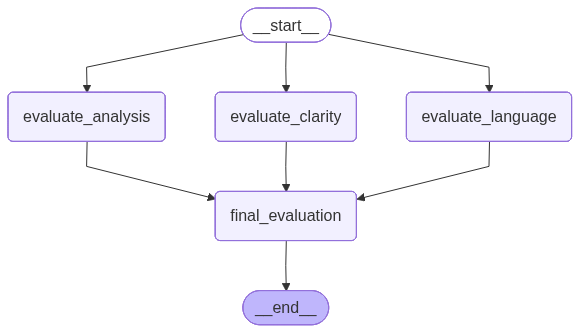

In [13]:
graph=StateGraph(EvaluationState)

# add nodes
graph.add_node("evaluate_language",evaluate_language)
graph.add_node("evaluate_analysis",evaluate_analysis)
graph.add_node("evaluate_clarity",evaluate_clarity)
graph.add_node("final_evaluation",final_evaluation)

# add edges
graph.add_edge(START,"evaluate_language")
graph.add_edge(START,"evaluate_analysis")
graph.add_edge(START,"evaluate_clarity")
graph.add_edge("evaluate_language","final_evaluation")
graph.add_edge("evaluate_analysis","final_evaluation")
graph.add_edge("evaluate_clarity","final_evaluation")
graph.add_edge("final_evaluation",END)

# compile
graph.compile()